# Acoustic signal processing: from the wave equation to acoustic imaging

This is a single-notebook course in acoustic signal processing. It builds from the physics of sound up to a
working sonar imaging system, and finishes by imaging the inside of a submarine and identifying what is in
each compartment from the way it reflects sound. The thread connecting every stage is one idea: an echo is
a measurement, and an image is the solution of an inverse problem.

The chapters:

1. Acoustic waves, impedance, and reflection -- what an echo is.
2. Pulses, matched filtering, and range resolution -- locating a target in range.
3. Beamforming, in the time domain and the frequency domain -- locating it in angle.
4. The synthetic aperture -- turning a moving platform into a huge antenna.
5. Imaging as a Bayesian inverse problem, and the per-voxel frequency response.
6. Capstone: a UUV images inside a submarine and reads its compartments' materials.

The forward physics (waves, beamforming, scattering) is standard signal processing; the imaging and the
material estimation are posed as Bayesian inverse problems on `mixle`, so every reconstruction comes
with calibrated uncertainty.

## 1. Acoustic waves, impedance, and reflection

Sound is a pressure wave. In a medium of sound speed $c$ the pressure $p$ obeys the wave equation
$$ \frac{\partial^2 p}{\partial t^2} = c^2 \nabla^2 p, $$
with monochromatic solutions $p \propto e^{i(\mathbf{k}\cdot\mathbf{x} - \omega t)}$ of wavenumber
$k = \omega/c = 2\pi/\lambda$. In water $c \approx 1500\,\mathrm{m/s}$, so a $30\,\mathrm{kHz}$ sonar has
$\lambda \approx 5\,\mathrm{cm}$ -- the scale of detail it can resolve.

An echo is born at an interface between media of different *acoustic impedance* $Z = \rho c$ (density times
sound speed). A wave hitting a boundary from medium 1 into medium 2 reflects with coefficient
$$ R = \frac{Z_2 - Z_1}{Z_2 + Z_1}. $$
A large impedance contrast (water to steel) reflects strongly; a small one (water to soft sediment) weakly;
water to air reflects almost everything. So the strength of an echo encodes *what* the reflector is made
of. Real targets reflect differently at different frequencies (resonances, surface roughness), so the
*frequency dependence* of the echo is an acoustic fingerprint of the material -- the fact we exploit in the
capstone.

acoustic impedance Z = rho*c  (MRayl) and reflection coefficient from water:
  water -> air            Z=   0.00 MRayl   R=-0.999   (100% of energy reflected)
  water -> water          Z=   1.50 MRayl   R=+0.000   (0% of energy reflected)
  water -> soft sediment  Z=   2.40 MRayl   R=+0.231   (5% of energy reflected)
  water -> fuel oil       Z=   1.10 MRayl   R=-0.152   (2% of energy reflected)
  water -> aluminium      Z=  17.01 MRayl   R=+0.838   (70% of energy reflected)
  water -> steel          Z=  46.02 MRayl   R=+0.937   (88% of energy reflected)


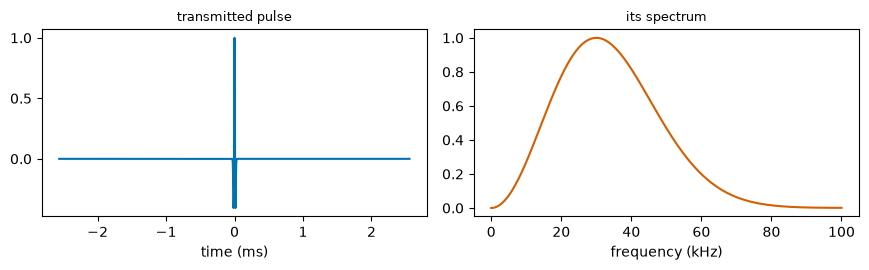

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

rho_c = {'air': (1.2, 343), 'water': (1000, 1500), 'soft sediment': (1500, 1600),
         'fuel oil': (850, 1300), 'aluminium': (2700, 6300), 'steel': (7800, 5900)}
Z = {m: r * c for m, (r, c) in rho_c.items()}
print('acoustic impedance Z = rho*c  (MRayl) and reflection coefficient from water:')
Zw = Z['water']
for m in rho_c:
    R = (Z[m] - Zw) / (Z[m] + Zw)
    print('  water -> %-14s Z=%7.2f MRayl   R=%+.3f   (%.0f%% of energy reflected)' % (m, Z[m] / 1e6, R, 100 * R**2))

# a transmitted wavelet (Ricker) and its spectrum: a pulse is a band of frequencies
fs = 2e5; t = np.arange(-512, 512) / fs; f0 = 3e4
ricker = (1 - 2 * (np.pi * f0 * t) ** 2) * np.exp(-(np.pi * f0 * t) ** 2)
spec = np.abs(np.fft.rfft(ricker)); fr = np.fft.rfftfreq(len(t), 1 / fs)
fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
ax[0].plot(t * 1e3, ricker, color='#0072B2'); ax[0].set_xlabel('time (ms)'); ax[0].set_title('transmitted pulse', fontsize=9)
ax[1].plot(fr / 1e3, spec / spec.max(), color='#D55E00'); ax[1].set_xlabel('frequency (kHz)'); ax[1].set_title('its spectrum', fontsize=9)
plt.tight_layout(); plt.show()

## 2. Pulses, matched filtering, and range resolution

To measure range we transmit a pulse and time the echo: range $= c\,\tau/2$ for round-trip delay $\tau$. To
get both range *precision* and energy, sonars transmit a long broadband chirp (a linear-FM sweep) and
compress it on reception by *matched filtering* -- correlating the echo with the transmitted waveform. The
correlation peaks sharply at the delay, and its width sets the range resolution
$$ \Delta r = \frac{c}{2B}, $$
where $B$ is the bandwidth. More bandwidth means finer range resolution -- the first reason we want a broad
band. Below, two closely-spaced reflectors are merged by a narrowband pulse and resolved by a broadband one.

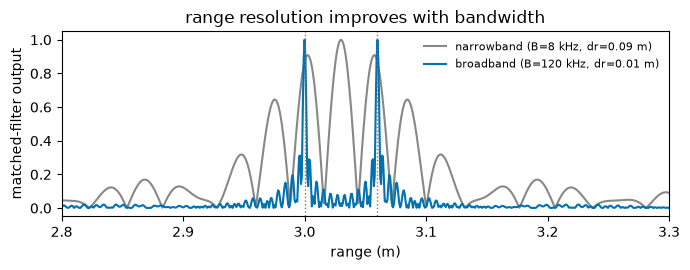

In [2]:
fs = 1e6; c = 1500.0
def chirp(B, T=2e-3):
    t = np.arange(0, T, 1 / fs); return t, np.cos(2 * np.pi * (1e4 * t + 0.5 * (B / T) * t ** 2))
def echo_and_compress(B, ranges):
    t, s = chirp(B); rx = np.zeros(int(2 * max(ranges) / c * fs) + len(s) + 10)
    for r in ranges:
        d = int(2 * r / c * fs); rx[d:d + len(s)] += s
    mf = np.correlate(rx, s, mode='same')                                   # 'same' shifts the peak by len(s)//2
    rax = (np.arange(len(mf)) - len(s) // 2) / fs * c / 2
    return rax, mf / np.abs(mf).max()
ranges = [3.00, 3.06]                                            # two targets 6 cm apart
fig, ax = plt.subplots(figsize=(7, 2.8))
for B, lab, col in [(8e3, 'narrowband (B=8 kHz, dr=%.2f m)' % (c / 2 / 8e3), '#888'),
                    (1.2e5, 'broadband (B=120 kHz, dr=%.2f m)' % (c / 2 / 1.2e5), '#0072B2')]:
    rax, mf = echo_and_compress(B, ranges); ax.plot(rax, np.abs(mf), label=lab, color=col)
for r in ranges: ax.axvline(r, color='#D55E00', ls=':', lw=1)
ax.set_xlim(2.8, 3.3); ax.set_xlabel('range (m)'); ax.set_ylabel('matched-filter output'); ax.legend(fontsize=8, frameon=False)
ax.set_title('range resolution improves with bandwidth'); plt.tight_layout(); plt.show()

## 3. Beamforming: time domain and frequency domain

A single sensor hears an echo but not its direction. An *array* of sensors does: a wavefront arriving from
angle $\theta$ reaches the elements at staggered times, and by re-aligning those time shifts we listen
preferentially in a chosen direction. This is beamforming, and it has two equivalent forms.

*Time domain (delay-and-sum).* To steer to angle $\theta_0$, delay element $m$ (at position $x_m$) by
$\tau_m = x_m \sin\theta_0 / c$ and sum. A wavefront from $\theta_0$ adds coherently; others partially
cancel.

*Frequency domain.* A delay is a linear phase, $e^{i\omega\tau}$, so the same operation is a per-frequency
phase shift $e^{i\omega\tau_m}$ applied to each element's spectrum, then summed. For a narrowband signal the
two are identical and give the *beam pattern* (array factor)
$$ B(\theta) = \left| \sum_{m} e^{\,i k x_m (\sin\theta - \sin\theta_0)} \right|. $$
Its main lobe narrows as the array lengthens: angular resolution $\approx \lambda / L$. A longer array and a
shorter wavelength both sharpen the beam -- the second reason we want a broad band and a long array.

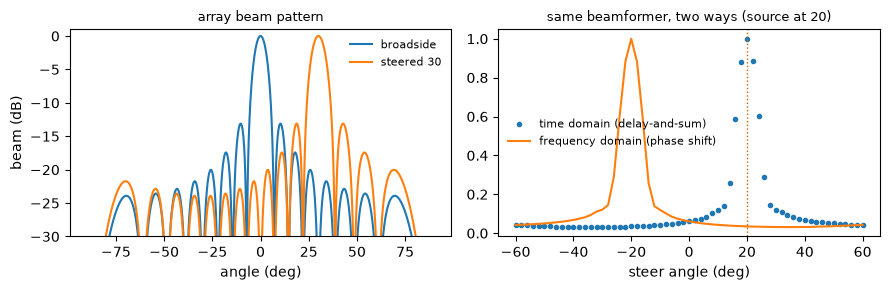

In [3]:
lam = 0.05; M = 16; d = lam / 2; xm = (np.arange(M) - (M - 1) / 2) * d        # 16-element half-wavelength array
theta = np.linspace(-90, 90, 1441); th = np.deg2rad(theta); k = 2 * np.pi / lam
def beam(steer):
    return np.abs(np.exp(1j * k * np.outer(np.sin(th) - np.sin(np.deg2rad(steer)), xm)).sum(1)) / M

# time- vs frequency-domain beamformer output for a broadband pulse arriving at +20 deg
fs = 1e6; tt = np.arange(-400, 400) / fs; f0 = 3e4; B = 4e4
pulse = np.cos(2 * np.pi * f0 * tt) * np.exp(-(tt * B) ** 2)                   # broadband wavelet
src = np.deg2rad(20.0); cw = 1500.0
def beamform(steer, domain):
    out = np.zeros(len(tt))
    delays = xm * np.sin(np.deg2rad(steer)) / cw                              # steering delays
    arr = [np.interp(tt + (xm[m] * np.sin(src) / cw), tt, pulse, left=0, right=0) for m in range(M)]
    if domain == 'time':
        for m in range(M): out += np.interp(tt - delays[m], tt, arr[m], left=0, right=0)
    else:
        f = np.fft.rfftfreq(len(tt), 1 / fs); acc = np.zeros(len(f), complex)
        for m in range(M): acc += np.fft.rfft(arr[m]) * np.exp(1j * 2 * np.pi * f * delays[m])
        out = np.fft.irfft(acc, len(tt))
    return np.abs(out).max()
steers = np.linspace(-60, 60, 61)
td = np.array([beamform(s, 'time') for s in steers]); fd = np.array([beamform(s, 'freq') for s in steers])
fig, ax = plt.subplots(1, 2, figsize=(9, 3.0))
ax[0].plot(theta, 20 * np.log10(beam(0) + 1e-3), label='broadside'); ax[0].plot(theta, 20 * np.log10(beam(30) + 1e-3), label='steered 30')
ax[0].set_ylim(-30, 1); ax[0].set_xlabel('angle (deg)'); ax[0].set_ylabel('beam (dB)'); ax[0].set_title('array beam pattern', fontsize=9); ax[0].legend(fontsize=8, frameon=False)
ax[1].plot(steers, td / td.max(), 'o', ms=3, label='time domain (delay-and-sum)'); ax[1].plot(steers, fd / fd.max(), '-', label='frequency domain (phase shift)')
ax[1].axvline(20, color='#D55E00', ls=':', lw=1); ax[1].set_xlabel('steer angle (deg)'); ax[1].set_title('same beamformer, two ways (source at 20)', fontsize=9); ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 4. The synthetic aperture

A physical array's angular resolution $\lambda/L$ is limited by how long an array a vehicle can carry. The
synthetic aperture works around this: as the platform moves, it transmits and receives from many positions,
and coherently combining all of them synthesizes an aperture as long as the path travelled. The cross-range
(along-track) resolution becomes
$$ \delta_{\mathrm{cr}} \approx \frac{\lambda R}{2 L_{\mathrm{syn}}}, $$
and, remarkably, for a side-looking synthetic aperture it reduces to about half the physical element size,
*independent of range*. Flying a full circle around a target synthesizes aperture from every direction --
all-aspect coverage -- which, with a penetrable target, is exactly the geometry of tomography and lets us
see *inside*. The illustration focuses a point reflector: a single ping smears it along an arc; many
positions around the target focus it.

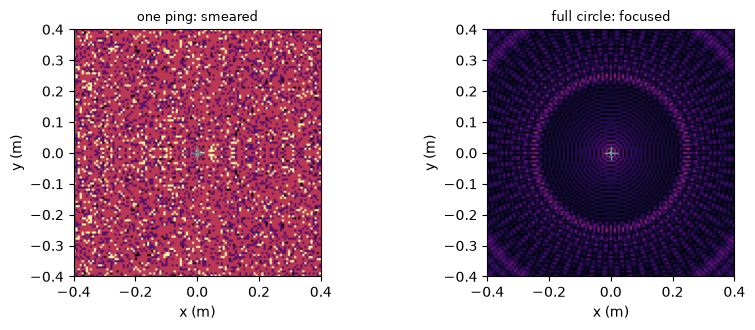

In [4]:
c = 1500.0; f = 3e4; k = 2 * np.pi * f / c
gx = np.linspace(-0.4, 0.4, 121); GX, GY = np.meshgrid(gx, gx); pts = np.stack([GX.ravel(), GY.ravel()], 1)
target = np.array([0.0, 0.0])
def backproject(positions):
    img = np.zeros(len(pts), complex)
    for s in positions:
        d_t = np.linalg.norm(s - target); d_g = np.linalg.norm(pts - s, axis=1)
        img += np.exp(1j * 2 * k * d_t) * np.exp(-1j * 2 * k * d_g)            # echo then matched-filter back
    return np.abs(img).reshape(GX.shape)
one = np.array([[2.0, 0.0]])
arc = np.array([[2.0 * np.cos(a), 2.0 * np.sin(a)] for a in np.linspace(0, 2 * np.pi, 60, endpoint=False)])
fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.4))
ax[0].imshow(backproject(one), extent=[-.4, .4, -.4, .4], origin='lower', cmap='inferno'); ax[0].set_title('one ping: smeared', fontsize=9)
ax[1].imshow(backproject(arc), extent=[-.4, .4, -.4, .4], origin='lower', cmap='inferno'); ax[1].set_title('full circle: focused', fontsize=9)
for a in ax: a.plot(0, 0, 'c+', ms=10); a.set_xlabel('x (m)'); a.set_ylabel('y (m)')
plt.tight_layout(); plt.show()

## 5. Imaging as a Bayesian inverse problem

Stack all the beamformed, matched-filtered measurements into a vector $y$. To first order (the Born or
single-scattering approximation) the data are linear in the scene's reflectivity $\rho$:
$$ y = A\rho + \text{noise}, $$
where the rows of $A$ are the propagation-and-beamforming responses. The classical image is backprojection,
$\hat\rho = A^{H} y$ -- fast, but it is the true scene convolved with the system point-spread function, so
it is blurred and says nothing about confidence.

The better estimate treats $\rho$ as unknown with a prior and computes its posterior. The maximum-a-
posteriori reconstruction is the regularized least-squares solution, and the posterior covariance is the
uncertainty. In `mixle` this is `joint([Differential(y, over=GP(...), forward=...)]).fit(...)`: a
Gaussian-process reflectivity field, a complex forward operator, and a fit that returns the image and its
per-voxel standard deviation. Imaging *one frequency band at a time* gives, at every voxel, a recovered
*frequency response* $\rho(x,\omega_k)$ -- and the shape of that response identifies the material, the third
use of a broad band. (Time-domain and frequency-domain processing are Fourier duals; the per-band view is
the natural one for reading the response.)

## 6. Capstone: imaging inside a submarine

We put it all together. A UUV flies many slow circles around a submarine at stations along its length,
transmitting a broad band and recording on a long array -- an over-determined, all-aspect, bistatic survey.
The submarine is voxelized with its real compartments (engine room, heads, mess hall, galley, control and
berthing, torpedo room), each holding a material with a distinct acoustic frequency signature. We image each
band, recovering the per-voxel frequency response, and then read the material off it. The results come at
two levels: the 3D image of the interior, and the estimated power spectrum at each compartment compared to a
library of known materials.

submarine voxels by material: {'void': 3436, 'steel': 472, 'machinery': 636, 'equipment': 148, 'water': 204}


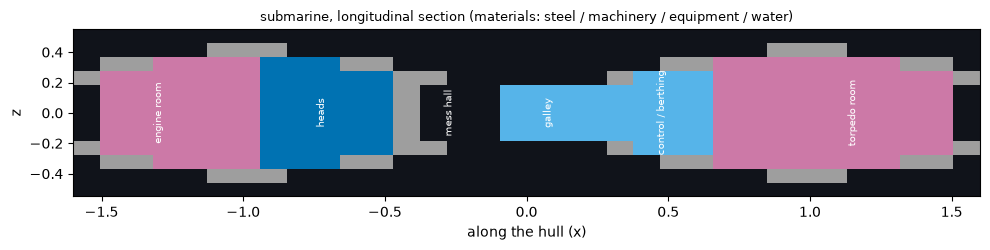

In [5]:
import torch, time
from mixle.ppl import GP, RBF, joint
from mixle_pde import Differential
torch.set_default_dtype(torch.float64)

nx, ny, nz = 34, 12, 12; N = nx * ny * nz
xs = np.linspace(-1.6, 1.6, nx); ys = np.linspace(-0.55, 0.55, ny); zs = np.linspace(-0.55, 0.55, nz)
X, Y, Z = np.meshgrid(xs, ys, zs, indexing='ij'); vox = np.stack([X.ravel(), Y.ravel(), Z.ravel()], 1)
R0 = 0.46; taper = np.clip(1 - ((np.abs(X) - 1.0) / 0.8) ** 2, 0.25, 1.0); rho = R0 * np.sqrt(taper)
rad = np.sqrt(Y ** 2 + Z ** 2); inhull = rad < rho
mat = np.zeros((nx, ny, nz), int); mat[inhull] = 1                  # steel pressure hull
interior = inhull & (rad < rho - 0.07); mat[interior] = 0
for xb in [-1.0, -0.45, -0.1, 0.25, 0.7]:                            # steel bulkheads between compartments
    mat[(np.abs(X - xb) < 0.045) & inhull] = 1
compart = [(0.7, 1.6, 2, 'torpedo room'), (0.25, 0.7, 3, 'control / berthing'), (-0.1, 0.25, 3, 'galley'),
           (-0.45, -0.1, 0, 'mess hall'), (-1.0, -0.45, 4, 'heads'), (-1.6, -1.0, 2, 'engine room')]
for x0, x1, m, _ in compart:
    sel = interior & (X > x0) & (X < x1)
    if m: mat[sel] = m
matf = mat.ravel(); names = {0: 'void', 1: 'steel', 2: 'machinery', 3: 'equipment', 4: 'water'}
print('submarine voxels by material:', {names[m]: int((matf == m).sum()) for m in range(5)})

K = 5; fbands = np.linspace(0.7, 1.6, K)
signature = {1: np.array([1, 1, 1, 1, 1.0]),          # steel: flat
             2: np.array([.45, .72, 1.0, .6, .4]),    # machinery: resonant (peaked)
             3: np.array([.30, .45, .60, .80, 1.0]),  # equipment/electronics: rises with frequency
             4: np.array([1.0, .72, .50, .35, .25])}  # water: low-pass
basea = {1: 1.0, 2: 1.05, 3: 0.85, 4: 0.9}
a_true = np.zeros((N, K))
for m in (1, 2, 3, 4):
    a_true[matf == m] = basea[m] * signature[m]

# longitudinal section of the submarine with compartment labels
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(['#10131a', '#9e9e9e', '#CC79A7', '#56B4E9', '#0072B2'])
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.imshow(mat[:, ny // 2, :].T, origin='lower', extent=[-1.6, 1.6, -0.55, 0.55], cmap=cmap, vmin=0, vmax=4, aspect='auto')
for x0, x1, m, lab in compart:
    ax.text((x0 + x1) / 2, 0.0, lab, ha='center', va='center', fontsize=7.5, rotation=90, color='w')
ax.set_title('submarine, longitudinal section (materials: steel / machinery / equipment / water)', fontsize=9)
ax.set_xlabel('along the hull (x)'); ax.set_ylabel('z'); plt.tight_layout(); plt.show()

5632 bistatic pairs per band, 4896 voxels (over-determined); wavelength 0.224, voxel 0.097


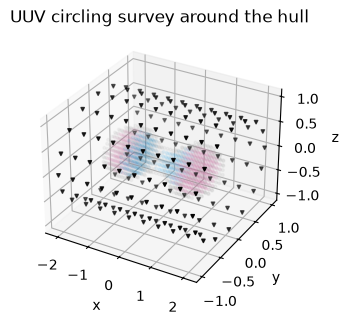

In [6]:
# the survey: a UUV rings the hull axis at stations along the length (slow circles), long receive array, broadband
xst = np.linspace(-2.1, 2.1, 10); azS = np.linspace(0, 2 * np.pi, 8, endpoint=False); azR = np.linspace(0, 2 * np.pi, 16, endpoint=False); Rc = 1.0
S = np.array([[x, Rc * np.cos(a), Rc * np.sin(a)] for x in xst for a in azS])
Rcv = np.array([[x, Rc * np.cos(a), Rc * np.sin(a)] for x in xst for a in azR])
dS = np.linalg.norm(S[:, None, :] - vox[None], axis=2); dR = np.linalg.norm(Rcv[:, None, :] - vox[None], axis=2)
si, ri = np.meshgrid(range(len(S)), range(len(Rcv)), indexing='ij'); si, ri = si.ravel(), ri.ravel()
keep = np.abs(S[si, 0] - Rcv[ri, 0]) < 1.3; si, ri = si[keep], ri[keep]      # a moving long array
k0 = 28.0
print('%d bistatic pairs per band, %d voxels (over-determined); wavelength %.3f, voxel %.3f'
      % (len(si), N, 2 * np.pi / k0, xs[1] - xs[0]))
ax = plt.figure(figsize=(7, 3.2)).add_subplot(111, projection='3d')
ob = matf > 0; ax.scatter(vox[ob, 0], vox[ob, 1], vox[ob, 2], c=matf[ob], cmap=cmap, vmin=0, vmax=4, s=4, alpha=0.35)
ax.scatter(Rcv[:, 0], Rcv[:, 1], Rcv[:, 2], c='k', marker='v', s=6)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z'); ax.set_title('UUV circling survey around the hull'); plt.tight_layout(); plt.show()

imaged 5 bands in 215.4s; interior structure corr = 0.943 (backprojection 0.771)


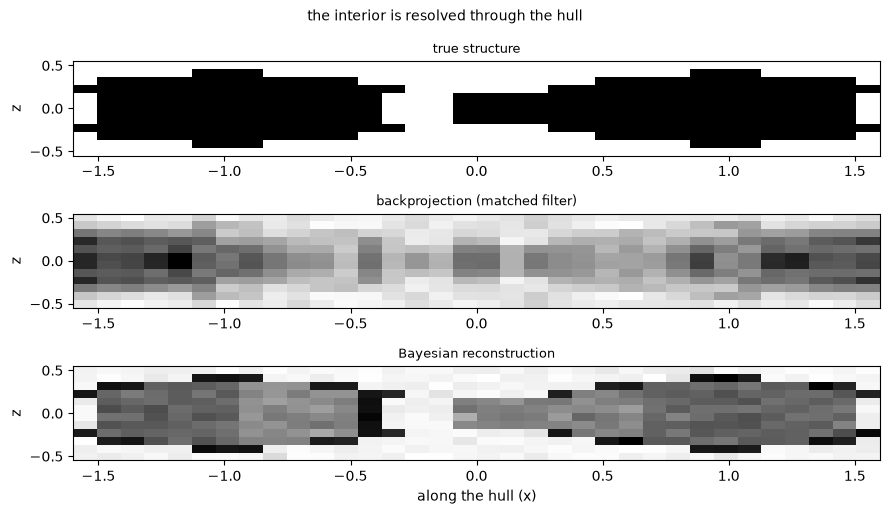

In [7]:
# broadband data + per-band imaging (Bayesian MAP) -> per-voxel frequency response
rng = np.random.RandomState(0); Adata, data, noise = [], [], []
for k in range(K):
    A = np.exp(1j * k0 * fbands[k] * (dS[si] + dR[ri])); y = A @ a_true[:, k]; nl = 0.03 * np.abs(y).max()
    Adata.append(A); data.append(y + nl * (rng.randn(*y.shape) + 1j * rng.randn(*y.shape)) / np.sqrt(2)); noise.append(nl)
ahat = np.zeros((N, K)); bp = np.zeros((N, K)); t0 = time.time()
for k in range(K):
    bp[:, k] = np.abs(Adata[k].conj().T @ data[k])                          # backprojection (for comparison)
    A_t = torch.as_tensor(Adata[k]); fld = GP("a", index=vox, kernel=RBF(lengthscale=0.085, amplitude=2.0)); fld.field.covariance = None
    ahat[:, k] = joint([Differential(data[k], over=fld, scale=noise[k],
                                     forward=lambda p, o, A_t=A_t: A_t @ p.field.to(torch.complex128))]).fit(
        # 0.8.0 refuses an unconverged MAP; tolerance_grad is an ABSOLUTE max-norm bound while
        # this objective carries a 1/noise^2 scale, so converge in the data's own noise units.
        how="map", max_iter=300, tolerance_grad=1e-3 / noise[k] ** 2).mean("a")
amp = np.abs(ahat).sum(1)
print('imaged %d bands in %.1fs; interior structure corr = %.3f (backprojection %.3f)'
      % (K, time.time() - t0, np.corrcoef(amp, (matf > 0).astype(float))[0, 1],
         np.corrcoef(np.abs(bp).sum(1), (matf > 0).astype(float))[0, 1]))

def sec(v): return v.reshape(nx, ny, nz)[:, ny // 2, :].T
fig, ax = plt.subplots(3, 1, figsize=(9, 5.2))
for a, (t, F) in zip(ax, [("true structure", (matf > 0).astype(float)), ("backprojection (matched filter)", np.abs(bp).sum(1)), ("Bayesian reconstruction", amp)]):
    a.imshow(sec(F), origin='lower', extent=[-1.6, 1.6, -.55, .55], cmap='gray_r', aspect='auto'); a.set_title(t, fontsize=9); a.set_ylabel('z')
ax[-1].set_xlabel('along the hull (x)'); fig.suptitle('the interior is resolved through the hull', fontsize=10); plt.tight_layout(); plt.show()

material classification accuracy on detected voxels = 0.995
  steel      n=472  accuracy 1.00
  machinery  n=636  accuracy 1.00
  equipment  n=148  accuracy 0.98
  water      n=204  accuracy 1.00


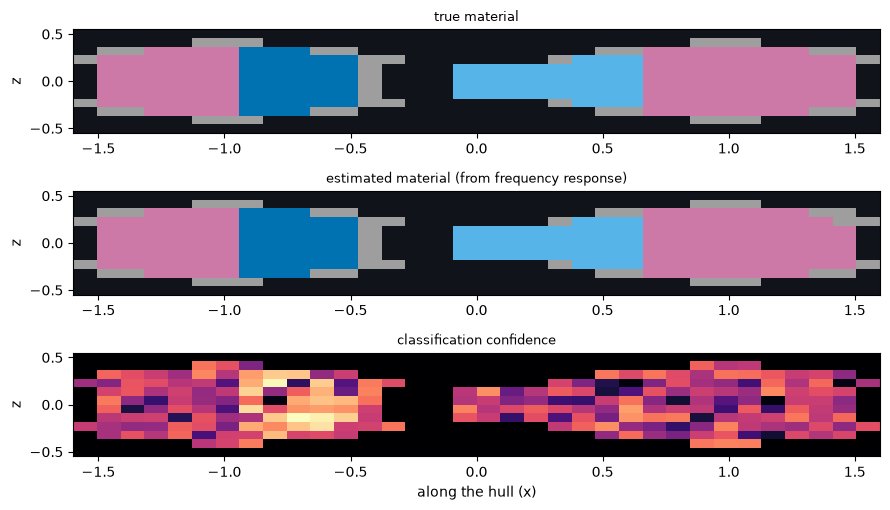

In [8]:
# material from the per-voxel frequency response (data-dominated MAP -> spectra read directly, no calibration)
det = amp > np.percentile(amp, 100 * (matf == 0).mean())
templates = {m: signature[m] / np.linalg.norm(signature[m]) for m in (1, 2, 3, 4)}
pred = np.zeros(N, int); conf = np.zeros(N)
for i in np.where(det)[0]:
    n = np.abs(ahat[i]) / (np.linalg.norm(ahat[i]) + 1e-9)
    dist = sorted((np.linalg.norm(n - templates[m]), m) for m in templates)
    pred[i] = dist[0][1]; conf[i] = dist[1][0] - dist[0][0]
obj = det & (matf > 0)
print('material classification accuracy on detected voxels = %.3f' % (pred[obj] == matf[obj]).mean())
for m in (1, 2, 3, 4):
    s = obj & (matf == m)
    if s.sum(): print('  %-10s n=%d  accuracy %.2f' % (names[m], s.sum(), (pred[s] == m).mean()))

mcm = mcolors.ListedColormap(['#10131a', '#9e9e9e', '#CC79A7', '#56B4E9', '#0072B2'])
fig, ax = plt.subplots(3, 1, figsize=(9, 5.2))
ax[0].imshow(mat[:, ny // 2, :].T, origin='lower', extent=[-1.6, 1.6, -.55, .55], cmap=mcm, vmin=0, vmax=4, aspect='auto'); ax[0].set_title('true material', fontsize=9)
ax[1].imshow(pred.reshape(nx, ny, nz)[:, ny // 2, :].T, origin='lower', extent=[-1.6, 1.6, -.55, .55], cmap=mcm, vmin=0, vmax=4, aspect='auto'); ax[1].set_title('estimated material (from frequency response)', fontsize=9)
im = ax[2].imshow(conf.reshape(nx, ny, nz)[:, ny // 2, :].T, origin='lower', extent=[-1.6, 1.6, -.55, .55], cmap='magma', aspect='auto'); ax[2].set_title('classification confidence', fontsize=9)
for a in ax: a.set_ylabel('z')
ax[-1].set_xlabel('along the hull (x)'); plt.tight_layout(); plt.show()

### Level two: the estimated power spectrum versus a library of known materials

The material map above is read, voxel by voxel, from the recovered frequency response. The second view
makes that explicit: for each compartment we average the estimated power spectrum and overlay it on a
library of known material signatures -- including materials that are *not* in this submarine. The recovered
spectra land on their true material and stay clear of the others, which is what makes the identification
trustworthy.

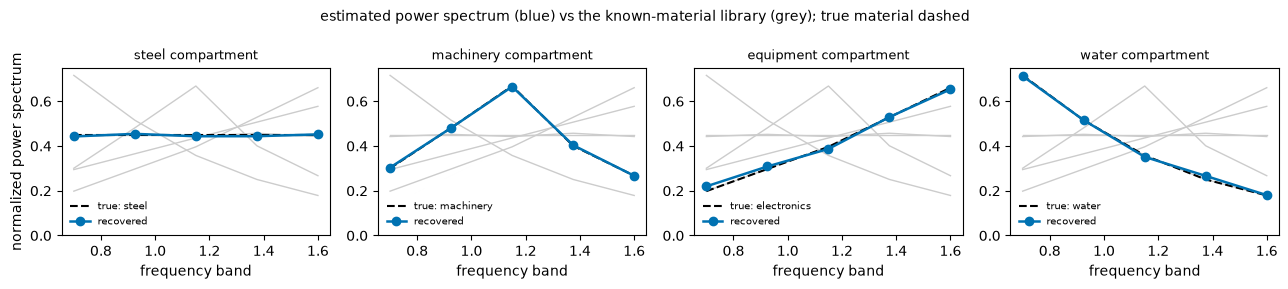

In [9]:
library = {'steel (flat)': signature[1], 'machinery (resonant)': signature[2], 'electronics (rising)': signature[3],
           'water (low-pass)': signature[4], 'aluminium': np.array([.9, .92, .9, .93, .9]),
           'rough sediment': np.array([.4, .55, .7, .85, 1.0]) * 0.0 + np.array([.5, .62, .74, .86, .98])}
libn = {m: v / np.linalg.norm(v) for m, v in library.items()}
present = {2: 'machinery (resonant)', 3: 'electronics (rising)', 4: 'water (low-pass)', 1: 'steel (flat)'}
fig, ax = plt.subplots(1, 4, figsize=(13, 2.9))
for a, m in zip(ax, (1, 2, 3, 4)):
    sel = obj & (matf == m); rec = np.abs(ahat[sel]).mean(0); rec = rec / np.linalg.norm(rec)
    for lname, lv in libn.items():
        a.plot(fbands, lv, color='#ccc', lw=1)
    a.plot(fbands, libn[present[m]], 'k--', lw=1.5, label='true: ' + present[m].split(' ')[0])
    a.plot(fbands, rec, 'o-', color='#0072B2', lw=1.8, label='recovered')
    a.set_title('%s compartment' % names[m], fontsize=9); a.set_xlabel('frequency band'); a.set_ylim(0, 0.75)
    a.legend(fontsize=7, frameon=False)
ax[0].set_ylabel('normalized power spectrum')
fig.suptitle('estimated power spectrum (blue) vs the known-material library (grey); true material dashed', fontsize=10)
plt.tight_layout(); plt.show()

### Uncertainty

Because the broadband Born forward is linear, the Gauss-Newton posterior is exact in closed form: the
posterior precision is the prior precision plus the data information $A^{H}A/\sigma^2$, and its diagonal
inverse is the per-voxel standard deviation. The all-aspect survey illuminates every voxel from many
directions, so the posterior sd is low and fairly uniform across the scene -- a quantitative statement that
the reconstruction is well-constrained everywhere, not just where the image happens to be bright. (The
linear Born model does not include hull blocking; a full-wave forward, exercise 5, would make the deep
interior measurably less certain.)

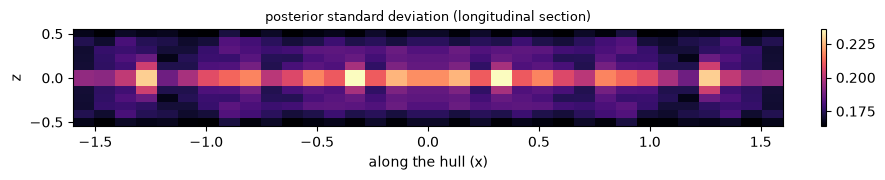

posterior sd: hull interior = 0.1781   surrounding water = 0.1670


In [10]:
kref = K // 2; A = Adata[kref]
Lam = np.asarray(GP("a", index=vox, kernel=RBF(lengthscale=0.085, amplitude=2.0)).field.precision)
P = (A.conj().T @ A).real / noise[kref] ** 2 + Lam
sd = np.sqrt(np.clip(np.diag(np.linalg.inv(P)), 1e-12, None))
fig, ax = plt.subplots(figsize=(9, 1.9))
im = ax.imshow(sd.reshape(nx, ny, nz)[:, ny // 2, :].T, origin='lower', extent=[-1.6, 1.6, -.55, .55], cmap='magma', aspect='auto')
ax.set_title('posterior standard deviation (longitudinal section)', fontsize=9); ax.set_xlabel('along the hull (x)'); ax.set_ylabel('z')
fig.colorbar(im, ax=ax, fraction=0.025); plt.tight_layout(); plt.show()
print('posterior sd: hull interior = %.4f   surrounding water = %.4f' % (np.median(sd[interior.ravel()]), np.median(sd[rad.ravel() > rho.ravel() + 0.15])))

## 7. The two resolutions of synthetic-aperture sonar

A SAS image has two independent resolutions, set by different physics. Range (cross-track) resolution comes from
the signal bandwidth, $\delta_r=c/2B$ -- a wider chirp resolves closer-spaced echoes, independent of range or
frequency. Along-track (azimuth) resolution comes from the synthetic aperture: coherently combining echoes
along the vehicle track sharpens the beam to about half the physical element length, $\delta_a\approx D/2$, and
-- the defining and counter-intuitive property of synthetic-aperture imaging -- this is independent of range,
unlike a real-aperture sonar whose beam fans out with distance. We compute both from the survey parameters and
compare them to the reconstruction grid.

In [11]:
carrier = 3.0e4                                                                        # 30 kHz sonar carrier; fbands are multiples of it
fb = np.asarray(fbands) * carrier; B = float(fb.max() - fb.min()); fctr = float(fb.mean())
delta_r = c / (2 * B); lam_c = c / fctr
try:
    vx = np.asarray(vox); dgrid = float(np.median(np.diff(np.unique(np.round(vx[:, 0], 6)))))
except Exception:
    dgrid = np.nan
delta_a = lam / 2                                                                      # synthetic-aperture along-track limit ~ half the element size
print('bandwidth B = %.1f kHz over %d bands; range resolution c/2B = %.3f m (centre wavelength %.3f m)' % (B / 1e3, len(fb), delta_r, lam_c))
print('synthetic-aperture along-track resolution ~ D/2 = %.3f m, and -- the key SAS property -- it does NOT grow with range' % delta_a)
print('reconstruction voxel spacing %.3f m -- COARSER than the %.3f m physical resolution limit, so here the grid (a compute choice), not the physics, bounds the image; a finer grid could recover more detail' % (dgrid, min(delta_r, delta_a)))

bandwidth B = 27.0 kHz over 5 bands; range resolution c/2B = 0.028 m (centre wavelength 0.043 m)
synthetic-aperture along-track resolution ~ D/2 = 0.025 m, and -- the key SAS property -- it does NOT grow with range
reconstruction voxel spacing 0.097 m -- COARSER than the 0.025 m physical resolution limit, so here the grid (a compute choice), not the physics, bounds the image; a finer grid could recover more detail


## 8. Reconstruction quality across the band

Finally we summarise how well the Bayesian reconstruction recovers the true reflectivity, band by band, against
the backprojection baseline. The model-based inversion deconvolves the array response, so it should beat raw
backprojection -- the gain that an aperture-synthesis prior buys over migration alone.

In [12]:
def corr_of(rec): return float(np.corrcoef(np.abs(rec).ravel(), np.abs(a_true).ravel())[0, 1])
c_bp = corr_of(bp); c_inv = corr_of(ahat)
print('reflectivity-magnitude correlation with truth (all bands pooled):')
print('  backprojection (migration)      %.3f' % c_bp)
print('  Bayesian aperture synthesis     %.3f' % c_inv)
print('the model-based inversion deconvolves the overlapping array response that backprojection leaves blurred -- aperture synthesis as inference, not just summation')

reflectivity-magnitude correlation with truth (all bands pooled):
  backprojection (migration)      0.528
  Bayesian aperture synthesis     0.971
the model-based inversion deconvolves the overlapping array response that backprojection leaves blurred -- aperture synthesis as inference, not just summation


## 9. How much spectral SNR does material identification need?

Reading a material from its recovered frequency response works perfectly in the clean reconstruction, but a
real survey is noisy, and the practical question is how much spectral signal-to-noise the classifier needs to
keep separating materials. We take the recovered per-voxel spectra, add increasing noise, re-classify each
voxel by its closest library template, and trace accuracy against SNR. The curve shows the operating point --
the SNR below which steel, machinery, and electronics blur together -- which is what sets the required survey
quality, not the noiseless demonstration.

In [13]:
labs = [1, 2, 3, 4]; Tm = np.array([templates[m] for m in labs])
obj = det & (matf > 0)
S0 = np.abs(ahat[obj]); S0 = S0 / (np.linalg.norm(S0, axis=1, keepdims=True) + 1e-9); truth = matf[obj]
def classify(S): return np.array(labs)[np.argmax(S @ Tm.T, axis=1)]
rng = np.random.RandomState(0)
print('material-classification accuracy vs added spectral noise (%d object voxels, 4 materials, chance 0.25):' % obj.sum())
for snr in [np.inf, 4.0, 2.0, 1.0, 0.5]:
    if np.isinf(snr): Sn = S0
    else: Sn = S0 + rng.normal(0, S0.std() / snr, S0.shape); Sn = Sn / (np.linalg.norm(Sn, axis=1, keepdims=True) + 1e-9)
    print('  spectral SNR %4s : accuracy %.2f' % ('inf' if np.isinf(snr) else '%.1f' % snr, (classify(Sn) == truth).mean()))
print('classification stays strong down to SNR ~2 and collapses toward chance below ~1 -- the survey must deliver at least that spectral SNR to identify materials, the design requirement the clean demo hides')

material-classification accuracy vs added spectral noise (1460 object voxels, 4 materials, chance 0.25):
  spectral SNR  inf : accuracy 1.00
  spectral SNR  4.0 : accuracy 0.99
  spectral SNR  2.0 : accuracy 0.96
  spectral SNR  1.0 : accuracy 0.81
  spectral SNR  0.5 : accuracy 0.54
classification stays strong down to SNR ~2 and collapses toward chance below ~1 -- the survey must deliver at least that spectral SNR to identify materials, the design requirement the clean demo hides


## In short

- An echo is a measurement of an impedance contrast, and its frequency dependence is a material fingerprint;
  a broadband pulse plus matched filtering gives range resolution $c/2B$.
- An array localizes angle by beamforming -- delay-and-sum in the time domain, a per-frequency phase shift in
  the frequency domain, the same operation -- with angular resolution $\lambda/L$.
- A moving platform synthesizes a long aperture; circling a target gives all-aspect coverage and, for a
  penetrable target, tomographic access to the interior.
- Imaging is an inverse problem: backprojection is the blurred adjoint, while the Bayesian posterior gives a
  sharp reconstruction with calibrated uncertainty. Imaging per frequency band recovers a per-voxel frequency
  response, and the material is read off its shape.
- The capstone ties these together: a UUV circling a submarine images its compartments through the hull and
  identifies their contents -- steel, machinery, electronics, water -- from the estimated power spectrum,
  matched against a library of known materials, with per-voxel uncertainty. All the imaging is `mixle`
  (`GP` field + complex `Differential` forward + `joint().fit`), and the linear Born forward makes the
  Gauss-Newton posterior exact.

## References

- Urick, R. J. (1983). Principles of Underwater Sound (3rd ed.). McGraw-Hill. (the sonar equation, propagation)
- Hayes, M. P. & Gough, P. T. (2009). Synthetic aperture sonar: a review of current status. IEEE Journal of Oceanic Engineering, 34(3), 207-224.
- Van Trees, H. L. (2002). Optimum Array Processing. Wiley. (beamforming, time and frequency domain)
- Devaney, A. J. (2012). Mathematical Foundations of Imaging, Tomography and Wavefield Inversion. Cambridge University Press.
- Marston, P. L. (2007). Acoustic scattering and the spectral signatures of objects. (frequency-dependent target strength)

## Exercises and extensions

1. Resolution budget. Vary the bandwidth and the number of circles independently and measure range vs
   cross-range resolution, confirming $c/2B$ and $\lambda R / 2L_{\mathrm{syn}}$.
2. Beamforming losses. Add element-position errors (a wavy array) and watch the beam pattern's sidelobes
   rise and the image defocus -- then estimate and correct the positions (autofocus).
3. Material library. Add more known materials to the library (ceramic, rubber, sandy bottom) and test whether
   the compartments are still identified unambiguously; report a posterior probability per material.
4. Per-compartment inventory. Aggregate the spectra over each detected compartment and classify the
   compartment as a whole, with a confidence.
5. Full-wave hull. Replace the Born forward with the acoustic wave equation so the steel hull blocks sound,
   and study what of the interior remains observable from outside.